# Polynomial Linear Regression

## What is Polynomial Linear Regression?

**Polynomial Linear Regression** is a machine learning model used when the relationship between your independent variable ($x$) and dependent variable ($y$) is **curved** rather than a straight line. 

While it fits a curve to the data, it is mathematically still considered a **linear** regression model.

---

### How It Works

In standard **Simple Linear Regression**, we try to fit a straight line using a first-degree equation:
$$y = \beta_0 + \beta_1 x$$

If your data curves (like a parabola or an "S" curve), a straight line will perform poorly. Polynomial regression solves this by adding higher-power terms ($x^2, x^3, \dots, x^n$) to the equation:
$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_n x^n$$

---

### Why is it still called "Linear"?

This is a very common point of confusion! It is called "linear" because the term **linear refers to the coefficients ($\beta$), not the exponent of the independent variable ($x$)**. 

* The coefficients ($\beta_0, \beta_1, \beta_2$, etc.) are all simple multipliers. 
* They are never raised to a power, squared, or buried inside a complex function (like $\sin(\beta)$ or $e^\beta$).
* Because of this, the mathematical optimization process remains entirely linear.

> **Analogy:** The machine learning algorithm treats $x^2$ simply as a brand-new, independent feature (like a new column in your dataset called $z$). It doesn't actually know or care that $z$ is mathematically derived from $x$.
------

### REGRESSION MODELS

#### Simple Linear Regression Formula:
$y = m_1x_1 + b$

#### Multiple Linear Regression Formula:
$y = m_1x_1 + m_2x_2 + \dots m_nx_n + b$

#### Polynomial Linear Regression Formula:
$y = m_1x_1 + m_2x_2^2 + \dots m_nx_n^n + b$

---
**Figure 22.1:** Formulas used by Regression Models
**************
**************
## When Polynomial Linear Regression is Used?

Polynomial Linear Regression is a form of regression analysis in which the relationship between the independent variable $x$ and the dependent variable $y$ is modeled as an $n$-th degree polynomial. 

While it models a non-linear relationship between the variables, it is still considered **linear** regression because the regression coefficients ($\beta_0, \beta_1, ..., \beta_n$) are linear.

---

### Key Scenarios for Use

You should choose Polynomial Regression over simple standard Linear Regression in the following situations:

*   **Non-Linear Relationships:** When the data points do not follow a straight line but instead show a curved trend (e.g., U-shaped, S-shaped, or exponential-looking curves).
*   **Theoretical Frameworks:** When the underlying physical, economic, or biological law governing the data is inherently polynomial (e.g., modeling the trajectory of a projectile, which follows a quadratic curve).
*   **Examining Residual Plots:** When a simple linear model leaves a distinct pattern (like a parabola) in the residual plot, indicating that the linear model failed to capture the structure of the data.

---

### Common Real-World Examples

| Application Area | Scenario Description |
| :--- | :--- |
| **Epidemiology** | Modeling the rise, peak, and fall of disease spread over time. |
| **Economics** | Analyzing the relationship between a country's GDP and its citizens' overall happiness or carbon emissions (e.g., the Kuznets Curve). |
| **Human Resources** | Predicting salary based on position level or years of experience, where growth accelerates drastically at higher levels. |
| **Engineering** | Measuring the yield of a chemical reaction based on varying temperatures. |

---

> ⚠️ **Important Caution: Overfitting**
> Increasing the degree of the polynomial ($n$) allows the model to fit complex curves tightly. However, setting the degree too high can lead to **overfitting**, where the model memorizes the noise in the training data and performs poorly on new, unseen data. Always validate your model using a test set or cross-validation!

# Program 1

## The dataset: Salary_Position.csv

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('Salary_Position.csv')
df

,Position,Level,Salary
0,Junior developer,1,35500
1,Senior developer,2,48000
2,Junior consultant,3,50000
3,Senior consultant,4,60555
4,Manager,5,80000
5,General Manager,6,110050
6,Regional Manager,7,155000
7,Country Manager,8,200000
8,Partner,9,295000
9,Senior Partner,10,500000


In [101]:
# retrive the 1st column and take it as independent variable(x) 
x = df[['Level']].values
x

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13]])

In [102]:
# 2nd column of the dataset should be taken as dependent variable(y)
y = df['Salary'].values
y

array([  35500,   48000,   50000,   60555,   80000,  110050,  155000,
        200000,  295000,  500000,  960000, 1190000, 3000000])

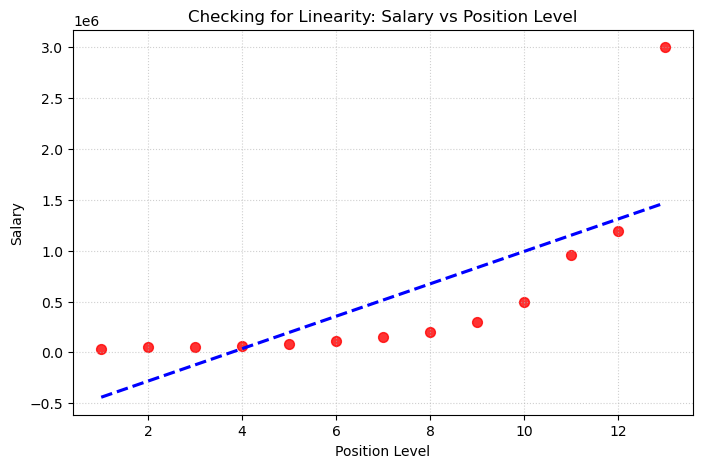

In [103]:
# Create scatter plot with a trendline

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.regplot(x='Level', y='Salary', data=df, ci=None, 
            scatter_kws={'color': 'red', 's': 50}, 
            line_kws={'color': 'blue', 'linestyle': '--'})

plt.title('Checking for Linearity: Salary vs Position Level')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [104]:
# Fit a Simple Linear Regression Model to understand how for it is suitable
from sklearn.linear_model import LinearRegression
linear_reg = LinearRegression()
linear_reg.fit(x, y)
y_pread = linear_reg.predict(x)

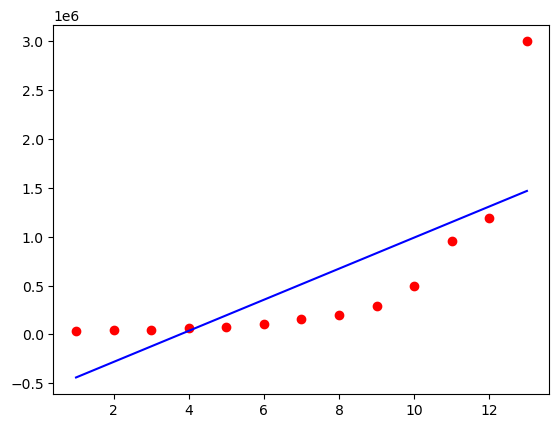

In [105]:
# disply the original data points (x and y ) along with the predicted data by SLR 
plt.scatter(x,y, color = 'red')
plt.plot(x,y_pread, color='blue')
plt.show()

In [106]:
# Fit a Polynomial Regression Model (Degree 4 to capture the curve)
from sklearn.preprocessing import PolynomialFeatures 
poly_feat = PolynomialFeatures(degree=4)
x_poly = poly_feat.fit_transform(x)

# apply PLR on this converted data x_poly along with y
# PLR is also same as Linear Regression but with additional terms. 
poly_reg = LinearRegression()
poly_reg.fit(x_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [107]:
y_pread = poly_reg.predict(x_poly)

<function matplotlib.pyplot.show(close=None, block=None)>

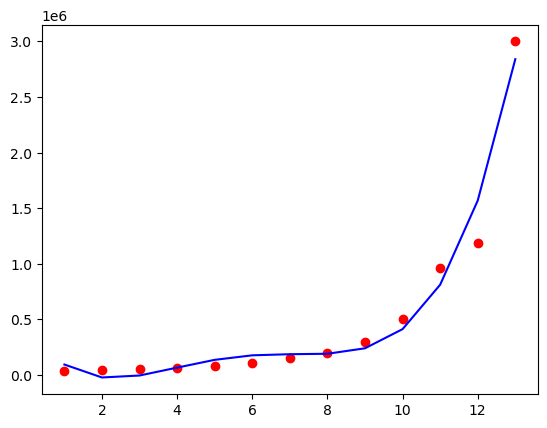

In [108]:
plt.scatter(x,y, color = 'red') 
plt.plot(x, y_pread , color = 'blue')
plt.show

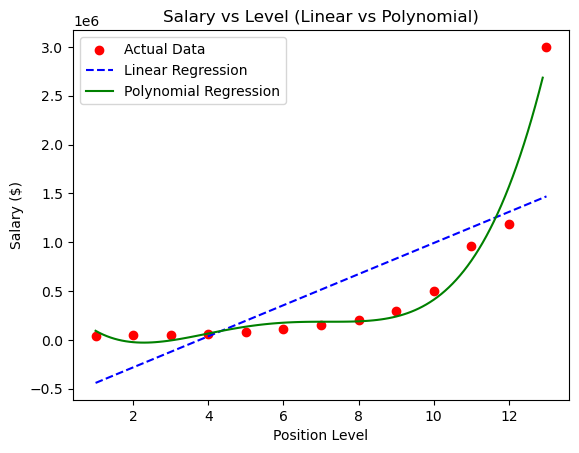

In [109]:
# Visualize the differences
plt.scatter(x, y, color='red', label='Actual Data')
plt.plot(x, linear_reg.predict(x), color='blue', linestyle='--', label='Linear Regression')

# Smooth out the polynomial curve line
# Flattenx or use .item() to extract the scalar values cleanly
X_grid = np.arange(min(x).item(), max(x).item(), 0.1).reshape(-1, 1)
plt.plot(X_grid, poly_reg.predict(poly_feat.fit_transform(X_grid)), color='green', label='Polynomial Regression')

plt.title('Salary vs Level (Linear vs Polynomial)')
plt.xlabel('Position Level')
plt.ylabel('Salary ($)')
plt.legend()
plt.show()

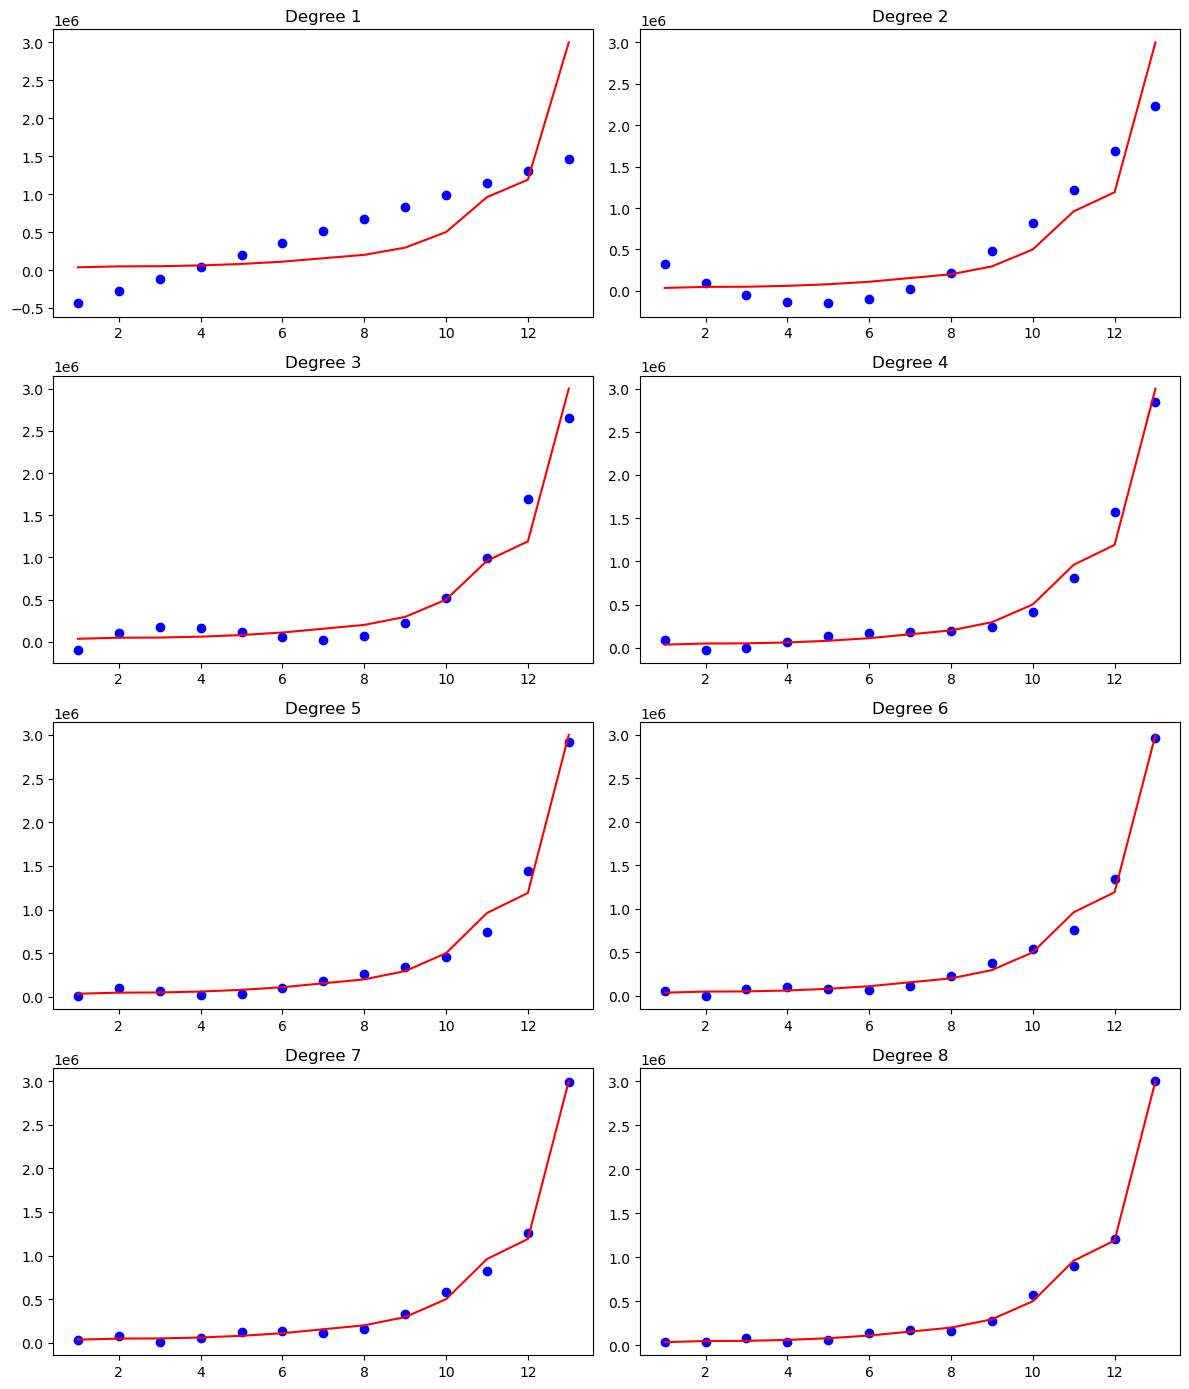

In [110]:
# Create the single large canvas OUTSIDE the loop
plt.figure(figsize=(12, 14)) 

# changing degree and plotting
for i in range(1, 9):
    poly_feat = PolynomialFeatures(degree=i)
    X_poly = poly_feat.fit_transform(x)
    poly_reg.fit(X_poly, y) 
    
    # This will now correctly carve up the canvas above
    plt.subplot(4, 2, i) 
    
    plt.scatter(x, poly_reg.predict(X_poly), color='blue')
    plt.plot(x, y, color='red') 
    plt.title(f'Degree {i}')

#  Move these outside the loop to render everything at the very end
plt.tight_layout() 
plt.show()

In [111]:
# degree 7 or 8 fitting the given points in best possible manner. 
# so let us use 7 in the model to fit the data 
poly_feat = PolynomialFeatures(degree=7) 
# convert x into polynomial regression with degree 7 
x_poly = poly_feat.fit_transform(x)

In [112]:
# apply polynomial regression on x_poly
poly_reg = LinearRegression() 
poly_reg.fit(x_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [113]:
# Import the r2_score function
from sklearn.metrics import r2_score

# Score of simple Linear Regression model
r2_score(y, linear_reg.predict(x)) 
linear_reg.score(x, y)

0.5537636591968075

In [114]:
# score of polynomial Linear Regression model 
r2_score(y, poly_reg.predict(x_poly))
poly_reg.score(x_poly, y)

0.9952325601658338

### questions
Predict salaries of enployees for Level 10 (Senior Partner) and Level 11 (MD)

In [115]:
# take as 2d array 
inputs = [[10],[11]]

# convert the 'inputs' into Polynomial Features of degree 7 
inputs1 = poly_feat.fit_transform(inputs)

# and then predict(inputs1)
poly_reg.predict(inputs1)

array([585184.15510016, 828604.60652905])

# Program-2
### Take salaryExperience.csv dataset and do analysis with Polynomial Linear Regression for the degree 5. Find te following
    a) Draw the scatter plot with regression line
    b) find coefficients
    c) intercept
    d) accuracy of your model and
    e) Judge the salary of an employee having 5.5 years of experience.

## Dataset given: Salary_Experience.csv

In [116]:
# Polynomial regression on salary and experience data  
import pandas as pd 
import matplotlib.pyplot as plt 

# load the dataset into dataframe object 
df = pd.read_csv('Salary_Experience.csv')
df

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [117]:
# retrieve 0th column as x and 1st as y 
x = df[['YearsExperience']].values
y = df['Salary'].values
print('x = ',x)
print('\ny = ',y)

x =  [[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]

y =  [ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  65308  66811  70253  72951  73424
  78442  83227  87009  85722  88909  95890  98341  92491 102786 102658]


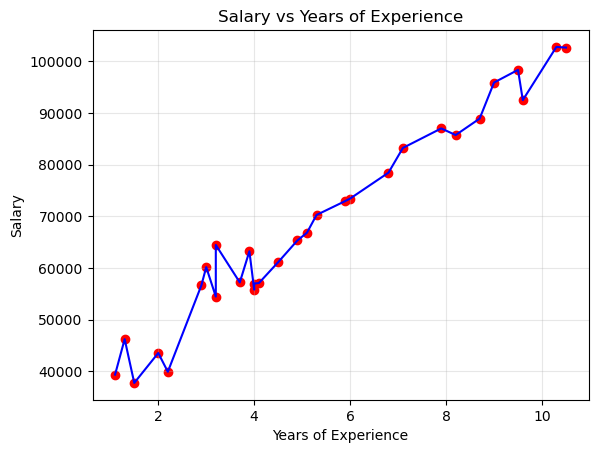

In [118]:
# draw scatter plot to know how data points are distributed 
# they are in wave form 
plt.scatter(x , y , color = 'red')
plt.plot(x , y , color = 'blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.grid(True, linestyle='-', alpha=0.3)
plt.show()

In [119]:
# create the Polynomial Features wih degree 5 
from sklearn.preprocessing import PolynomialFeatures
pf = PolynomialFeatures(degree = 5)

In [120]:
# convert x using the polynomal features of degree of 5 
x1 = pf.fit_transform(x)

In [121]:
# create the Polynomial Regression Model 
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [122]:
# train the model on x1 and y 
lr.fit(x1, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [123]:
# calculate the accuracy with degree = 5 
lr.score(x1, y)

0.963613501814622

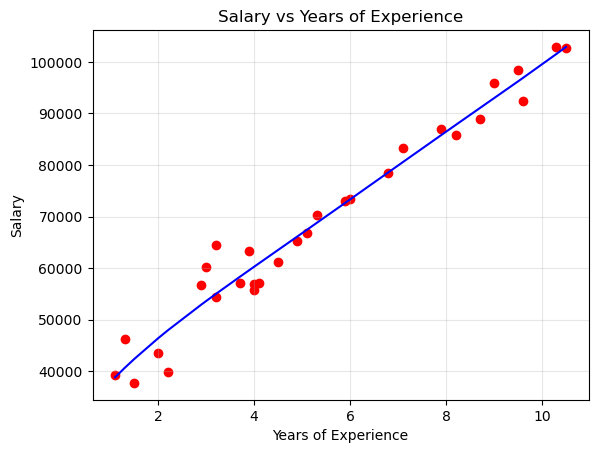

In [124]:
# draw the points along with regression line 
plt.scatter(x, y, color = 'red')
plt.plot(x, lr.predict(x1) , color = 'blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.grid(True, linestyle='-', alpha=0.3)
plt.show()

In [125]:
# find the coefficient 
# since degree is 5 we will have five coefficients 
print('Coefficients :',lr.coef_)

Coefficients : [ 0.00000000e+00  1.29358842e+04 -2.14496649e+03  3.45899891e+02
 -2.68677302e+01  8.06572898e-01]


In [126]:
# find intercept 
# we will have only one intercept 
print('Intercept :',lr.intercept_)

Intercept : 26758.280664045058


In [127]:
# judge the salary of employee with 5.5 yrs of experience 
# input in 2d output will be in 1d array form 
inputs = [[5.5]]
inputs1 = pf.fit_transform(inputs)
result = lr.predict(inputs1)
print("Salary for 5.5 yrs Experience :",result)

Salary for 5.5 yrs Experience : [70043.20486397]


# -- Ends Here --